In [1]:
import os
import pandas as pd
import numpy as np
import scanpy as sc
import plotly.express as px

# === INPUT PATHS ===
input_folder = "/home/ajarrah/PhD_Thesis/chapter_2/h5ad_data_processed_4lockmasses_filtered/"
common_mzs_csv_input_path = "/home/ajarrah/PhD_Thesis/chapter_2/csv_data/common_mz_clusters_improved.csv"
image_output_folder = "/home/ajarrah/PhD_Thesis/chapter_2/results/filtered_new/vmax/images_individual"
results_output_folder = "/home/ajarrah/PhD_Thesis/chapter_2/results/filtered_new/vmax/"

In [2]:
# Your list of sample IDs (also used as keys in the dictionary)
aad_1 = sc.read_h5ad(os.path.join(input_folder, "aad_1_filtered.h5ad"))
aad_2 = sc.read_h5ad(os.path.join(input_folder, "aad_2_filtered.h5ad"))
aad_3 = sc.read_h5ad(os.path.join(input_folder, "aad_3_filtered.h5ad"))
aad_4 = sc.read_h5ad(os.path.join(input_folder, "aad_4_filtered.h5ad"))
ac_1 = sc.read_h5ad(os.path.join(input_folder, "ac_1_filtered.h5ad"))
ac_2 = sc.read_h5ad(os.path.join(input_folder, "ac_2_filtered.h5ad"))
ac_3 = sc.read_h5ad(os.path.join(input_folder, "ac_3_filtered.h5ad"))
ac_4 = sc.read_h5ad(os.path.join(input_folder, "ac_4_filtered.h5ad"))
yad_1 = sc.read_h5ad(os.path.join(input_folder, "yad_1_filtered.h5ad"))
yad_2 = sc.read_h5ad(os.path.join(input_folder, "yad_2_filtered.h5ad"))
yad_3 = sc.read_h5ad(os.path.join(input_folder, "yad_3_filtered.h5ad"))
yad_4 = sc.read_h5ad(os.path.join(input_folder, "yad_4_filtered.h5ad"))
yc_1 = sc.read_h5ad(os.path.join(input_folder, "yc_1_filtered.h5ad"))
yc_2 = sc.read_h5ad(os.path.join(input_folder, "yc_2_filtered.h5ad"))
yc_3 = sc.read_h5ad(os.path.join(input_folder, "yc_3_filtered.h5ad"))
yc_4 = sc.read_h5ad(os.path.join(input_folder, "yc_4_filtered.h5ad"))

In [3]:
sample_list = [
    aad_1, aad_2, aad_3, aad_4,
    ac_1, ac_2, ac_3, ac_4,
    yad_1, yad_2, yad_3, yad_4,
    yc_1, yc_2, yc_3, yc_4
]

sample_ids = [
    "aad_1", "aad_2", "aad_3", "aad_4",
    "ac_1", "ac_2", "ac_3", "ac_4",
    "yad_1", "yad_2", "yad_3", "yad_4",
    "yc_1", "yc_2", "yc_3", "yc_4"
]

# Map sample ID → AnnData object
sample_map = dict(zip(sample_ids, sample_list))


In [4]:
# Assuming sample_list contains your AnnData objects and their variable names are like 'aad_1', 'ac_1', etc.
# They must be defined variables or in a dictionary for easy iteration.

# Example: if you have them in a dictionary like sample_map = {'aad_1': aad_1, ...}

for sample_id in sample_list:
    adata = sample_id  # Get the AnnData object by variable name string
    # Sum all intensities for each spot (row) across all m/z (columns)
    tic = adata.X.sum(axis=1)  # shape (n_spots, 1) or (n_spots,) depending on sparse or dense
    
    # If sparse, convert to flat array
    if hasattr(tic, "A1"):  # sparse matrix
        tic = tic.A1
    else:
        tic = np.asarray(tic).flatten()

    # Add TIC as a new column in obs
    adata.obs["Processed_TIC"] = tic

In [5]:
# === STEP 3: Load common m/z list ===
common_mz_df = pd.read_csv(common_mzs_csv_input_path)
common_mz_df

,mzs,group,sample,common_group_name
0,326.1934,YC,1,326.1934
1,326.1937,AC,3,326.1934
2,326.1937,AC,4,326.1934
3,326.1937,AC,2,326.1934
4,326.1937,YC,3,326.1934
...,...,...,...,...
8443,1088.8307,YAD,1,1088.8161
8444,1088.8307,YAD,3,1088.8161
8445,1088.8313,YC,2,1088.8161
8446,1088.8316,AAD,1,1088.8161


In [6]:

# Example: convert group/sample to sample_id that matches your sample_map keys
def make_sample_id(row):
    # lower group, then underscore, then sample number
    return f"{row['group'].lower()}_{row['sample']}"

common_mz_df['sample_id'] = common_mz_df.apply(make_sample_id, axis=1)
print(common_mz_df)

            mzs group  sample  common_group_name sample_id
0      326.1934    YC       1           326.1934      yc_1
1      326.1937    AC       3           326.1934      ac_3
2      326.1937    AC       4           326.1934      ac_4
3      326.1937    AC       2           326.1934      ac_2
4      326.1937    YC       3           326.1934      yc_3
...         ...   ...     ...                ...       ...
8443  1088.8307   YAD       1          1088.8161     yad_1
8444  1088.8307   YAD       3          1088.8161     yad_3
8445  1088.8313    YC       2          1088.8161      yc_2
8446  1088.8316   AAD       1          1088.8161     aad_1
8447  1088.8316   AAD       2          1088.8161     aad_2

[8448 rows x 5 columns]


In [7]:
pivot_df = common_mz_df.pivot(index='sample_id', columns='common_group_name', values='mzs')
pivot_df

common_group_name,326.1934,337.1867,339.2243,340.2283,341.2403,351.1655,351.2252,352.2294,353.2401,354.2482,...,995.6423,996.6482,998.6634,999.6775,1000.6777,1001.6889,1002.6913,1003.7043,1017.6613,1088.8161
sample_id,,,,,,,,,,,,,,,,,,,,,
aad_1,326.1996,337.1939,339.2315,340.2354,341.2474,351.1722,351.2319,352.2361,353.2467,354.2548,...,995.6523,996.6534,998.6688,999.6829,1000.6882,1001.6944,1002.7016,1003.7048,1017.6676,1088.8316
aad_2,326.1996,337.1939,339.2315,340.2354,341.2474,351.1722,351.2319,352.2361,353.2467,354.2548,...,995.6523,996.6534,998.6688,999.6829,1000.6882,1001.6944,1002.7016,1003.7048,1017.6676,1088.8316
aad_3,326.1996,337.1939,339.2315,340.2354,341.2474,351.1722,351.2319,352.2361,353.2467,354.2530,...,995.6523,996.6534,998.6688,999.6829,1000.6832,1001.6944,1002.7016,1003.7048,1017.6626,1088.8262
aad_4,326.1996,337.1939,339.2315,340.2354,341.2474,351.1722,351.2319,352.2361,353.2467,354.2530,...,995.6523,996.6534,998.6688,999.6829,1000.6882,1001.6944,1002.7016,1003.7048,1017.6676,1088.8262
ac_1,326.1996,337.1939,339.2315,340.2354,341.2457,351.1722,351.2319,352.2361,353.2467,354.2548,...,995.6523,996.6534,998.6688,999.6829,1000.6882,1001.6944,1002.7016,1003.7098,1017.6676,1088.8262
ac_2,326.1937,337.1885,339.2262,340.2302,341.2405,351.1674,351.2254,352.2314,353.2420,354.2502,...,995.6473,996.6484,998.6636,999.6777,1000.6829,1001.6891,1002.6963,1003.7045,1017.6616,1088.8166
ac_3,326.1937,337.1868,339.2262,340.2285,341.2405,351.1674,351.2254,352.2314,353.2420,354.2484,...,995.6473,996.6484,998.6636,999.6777,1000.6779,1001.6891,1002.6963,1003.7045,1017.6616,1088.8166
ac_4,326.1937,337.1868,339.2262,340.2285,341.2405,351.1674,351.2254,352.2314,353.2420,354.2484,...,995.6423,996.6484,998.6636,999.6777,1000.6779,1001.6891,1002.6913,1003.7045,1017.6616,1088.8166
yad_1,326.1991,337.1919,339.2312,340.2334,341.2454,351.1719,351.2299,352.2358,353.2464,354.2528,...,995.6518,996.6579,998.6682,999.6824,1000.6876,1001.6989,1002.7011,1003.7093,1017.6721,1088.8307


In [8]:
order = [
    'yc_1', 'yc_2', 'yc_3', 'yc_4',
    'yad_1', 'yad_2', 'yad_3', 'yad_4',
    'ac_1', 'ac_2', 'ac_3', 'ac_4',
    'aad_1', 'aad_2', 'aad_3', 'aad_4'
]

# Assuming pivot_df is your pivoted DataFrame with index = sample_id
pivot_df_sorted = pivot_df.loc[pivot_df.index.intersection(order)]
pivot_df_sorted = pivot_df_sorted.loc[order]

pivot_df_sorted

common_group_name,326.1934,337.1867,339.2243,340.2283,341.2403,351.1655,351.2252,352.2294,353.2401,354.2482,...,995.6423,996.6482,998.6634,999.6775,1000.6777,1001.6889,1002.6913,1003.7043,1017.6613,1088.8161
sample_id,,,,,,,,,,,,,,,,,,,,,
yc_1,326.1934,337.1867,339.2243,340.2283,341.2403,351.1655,351.2252,352.2294,353.2401,354.2482,...,995.6471,996.6482,998.6634,999.6775,1000.6777,1001.6889,1002.6961,1003.7043,1017.6613,1088.8161
yc_2,326.1993,337.1920,339.2313,340.2335,341.2455,351.1721,351.2300,352.2360,353.2465,354.2529,...,995.6521,996.6532,998.6685,999.6827,1000.6879,1001.6942,1002.7014,1003.7097,1017.6674,1088.8313
yc_3,326.1937,337.1868,339.2245,340.2284,341.2405,351.1657,351.2254,352.2296,353.2401,354.2484,...,995.6474,996.6485,998.6637,999.6778,1000.6780,1001.6892,1002.6964,1003.7046,1017.6617,1088.8167
yc_4,326.1989,337.1917,339.2310,340.2332,341.2451,351.1717,351.2296,352.2356,353.2462,354.2526,...,995.6516,996.6528,998.6681,999.6822,1000.6874,1001.6937,1002.7009,1003.7092,1017.6669,1088.8250
yad_1,326.1991,337.1919,339.2312,340.2334,341.2454,351.1719,351.2299,352.2358,353.2464,354.2528,...,995.6518,996.6579,998.6682,999.6824,1000.6876,1001.6989,1002.7011,1003.7093,1017.6721,1088.8307
yad_2,326.1991,337.1936,339.2312,340.2334,341.2454,351.1719,351.2299,352.2358,353.2464,354.2528,...,995.6518,996.6579,998.6682,999.6824,1000.6876,1001.6989,1002.7011,1003.7093,1017.6721,1088.8307
yad_3,326.1991,337.1936,339.2312,340.2351,341.2454,351.1719,351.2316,352.2358,353.2464,354.2545,...,995.6518,996.6579,998.6682,999.6824,1000.6876,1001.6989,1002.7011,1003.7093,1017.6670,1088.8307
yad_4,326.1991,337.1919,339.2312,340.2334,341.2454,351.1719,351.2299,352.2358,353.2464,354.2528,...,995.6518,996.6579,998.6682,999.6824,1000.6876,1001.6939,1002.7011,1003.7093,1017.6721,1088.8307
ac_1,326.1996,337.1939,339.2315,340.2354,341.2457,351.1722,351.2319,352.2361,353.2467,354.2548,...,995.6523,996.6534,998.6688,999.6829,1000.6882,1001.6944,1002.7016,1003.7098,1017.6676,1088.8262


In [9]:
from matplotlib.colors import LinearSegmentedColormap
# === COLOR SCALE ===
custom_cmap = LinearSegmentedColormap.from_list("custom_scale", [
    (0.0, "#454545"),   # white
    (0.00000001, "#000000"),  # black
    (0.10, "#000080"),  # navy
    (0.15, "#0000FF"),  # blue
    (0.30, "#8000FF"),  # purple-ish
    (0.45, "#FF0000"),  # red
    (0.60, "#FF8000"),  # orange
    (0.75, "#FFFF00"),  # yellow
    (1.0, "#FFFFFF")   # white
])

In [10]:
# Create output folder if it doesn't exist
os.makedirs(image_output_folder, exist_ok=True)

In [11]:
pivot_df_sorted.columns

Index([ 326.1934,  337.1867,  339.2243,  340.2283,  341.2403,  351.1655,
        351.2252,  352.2294,  353.2401,  354.2482,
       ...
        995.6423,  996.6482,  998.6634,  999.6775, 1000.6777, 1001.6889,
       1002.6913, 1003.7043, 1017.6613, 1088.8161],
      dtype='float64', name='common_group_name', length=528)

In [13]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_single_mz_animal(
    adata,
    mz_val,
    sample_id,
    output_folder,
    tol=0.001,
    vmax_percentile=99.9,
    figsize=(6, 5),
    cmap=None
):
    """
    Plot TIC-normalized intensity for one m/z and one sample.

    Parameters
    ----------
    adata : AnnData
        The AnnData object containing MSI data.
    mz_val : float
        Target m/z value to extract.
    sample_id : str
        Name of the animal/sample (used in figure title and filename).
    output_folder : str
        Path to folder where the image will be saved.
    tol : float, optional
        Tolerance for matching m/z value. Default is 0.001.
    vmax_percentile : float, optional
        Percentile for vmax scaling (default 99.9).
    figsize : tuple, optional
        Figure size in inches (default (6,5)).
    cmap : matplotlib colormap, optional
        Colormap to use. If None, defaults to "viridis".
    """

    # --- Extract m/z index ---
    mz_axis = adata.var_names.astype(float).values
    mz_diff = np.abs(mz_axis - mz_val)
    if np.min(mz_diff) > tol:
        print(f"m/z {mz_val} not found within tolerance {tol}")
        return
    mz_index = np.argmin(mz_diff)

    # --- Extract intensities ---
    intensities = adata.X[:, mz_index].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[:, mz_index]

    # --- Extract coordinates & TIC ---
    x = adata.obs["x"].values
    y = adata.obs["y"].values
    tic = adata.obs["Processed_TIC"].values

    # Normalize by TIC
    normalized_intensities = intensities / tic
    normalized_intensities = np.nan_to_num(normalized_intensities, nan=0.0, posinf=0.0, neginf=0.0)

    # --- Color scaling ---
    vmax_value = np.percentile(normalized_intensities, vmax_percentile)

    # --- Plot ---
    plt.figure(figsize=figsize)
    sc = plt.scatter(x, y, c=normalized_intensities,
                     cmap=cmap if cmap else "viridis",
                     marker='s', s=8, edgecolor='none',
                     vmin=0, vmax=vmax_value)
    plt.title(f"{sample_id} m/z={mz_val:.4f} TIC Normalized")
    plt.axis("off")
    plt.colorbar(sc, fraction=0.046, pad=0.04)

    # --- Save ---
    os.makedirs(output_folder, exist_ok=True)
    out_path = os.path.join(output_folder, f"{sample_id}_mz{mz_val:.4f}.png")
    #plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

    print(f"Saved: {out_path}")

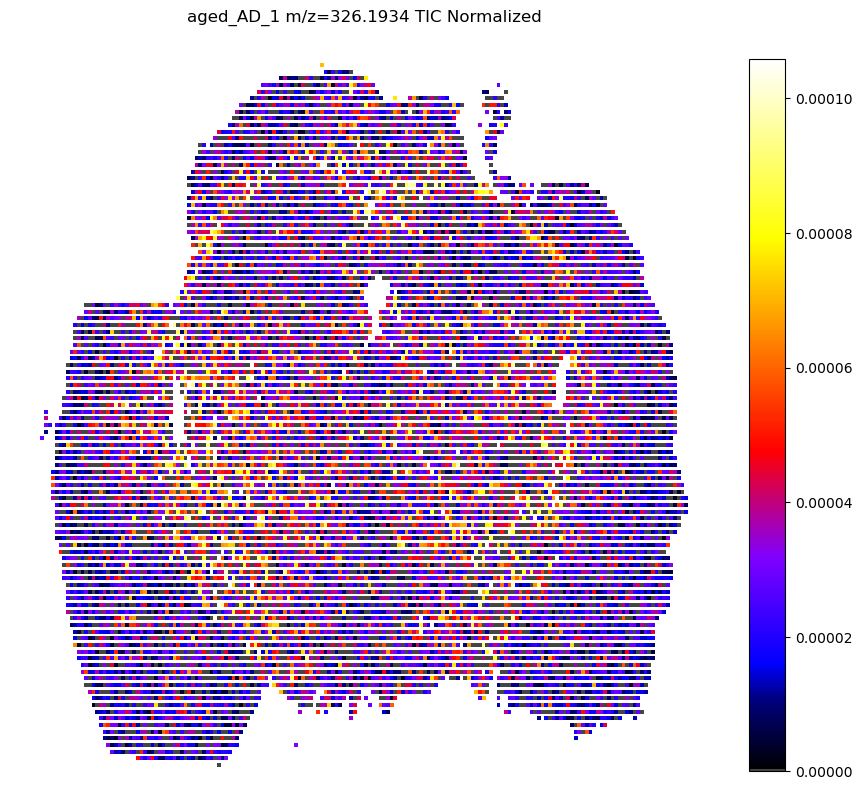

Saved: /home/ajarrah/PhD_Thesis/chapter_2/results/filtered_new/vmax/images_individual_tic/aged_AD_1_mz326.1934.png


In [20]:
plot_single_mz_animal(
    adata=aad_1,
    mz_val=326.1934,
    tol=0.1,
    sample_id="aged_AD_1",
    output_folder=image_output_folder + "_tic",
    vmax_percentile=99.5,
    figsize=(10, 10),
    cmap=custom_cmap
)


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_single_mz_animal(
    adata,
    mz_val,
    tol=0.001,
    vmax_percentile=99.9,
    square_size=60,   # µm per pixel (both x and y)
    cmap=None
):
    """
    Plot TIC-normalized intensity for one m/z and one sample, with each square
    representing 'square_size' µm × 'square_size' µm.
    """

    # --- Extract m/z index ---
    mz_axis = adata.var_names.astype(float).values
    mz_diff = np.abs(mz_axis - mz_val)
    if np.min(mz_diff) > tol:
        print(f"m/z {mz_val} not found within tolerance {tol}")
        return
    mz_index = np.argmin(mz_diff)

    # --- Extract intensities ---
    intensities = adata.X[:, mz_index].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[:, mz_index]

    # --- Extract coordinates & TIC ---
    x = adata.obs["x"].values
    y = adata.obs["y"].values
    tic = adata.obs["Processed_TIC"].values

    # Normalize by TIC
    normalized_intensities = intensities / tic
    normalized_intensities = np.nan_to_num(normalized_intensities, nan=0.0, posinf=0.0, neginf=0.0)

    # --- Build a grid ---
    x_unique = np.unique(x)
    y_unique = np.unique(y)
    x_size = len(x_unique)
    y_size = len(y_unique)

    # Map intensities to grid
    grid = np.full((y_size, x_size), np.nan)
    for xi, yi, val in zip(x, y, normalized_intensities):
        x_idx = np.where(x_unique == xi)[0][0]
        y_idx = np.where(y_unique == yi)[0][0]
        grid[y_idx, x_idx] = val

    # --- Color scaling ---
    vmax_value = np.percentile(normalized_intensities, vmax_percentile)

    # --- Plot ---
    extent = [x.min(), x.max() + square_size, y.min(), y.max() + square_size]  # in µm
    plt.figure(figsize=(x_size * square_size / 1000, y_size * square_size / 1000))  
    # scale figure size in mm (1000 µm = 1 mm)

    plt.imshow(grid, cmap=cmap if cmap else "viridis",
               origin="lower", extent=extent,
               vmin=0, vmax=vmax_value, interpolation="none")

    plt.axis("equal")
    plt.axis("off")
    plt.show()


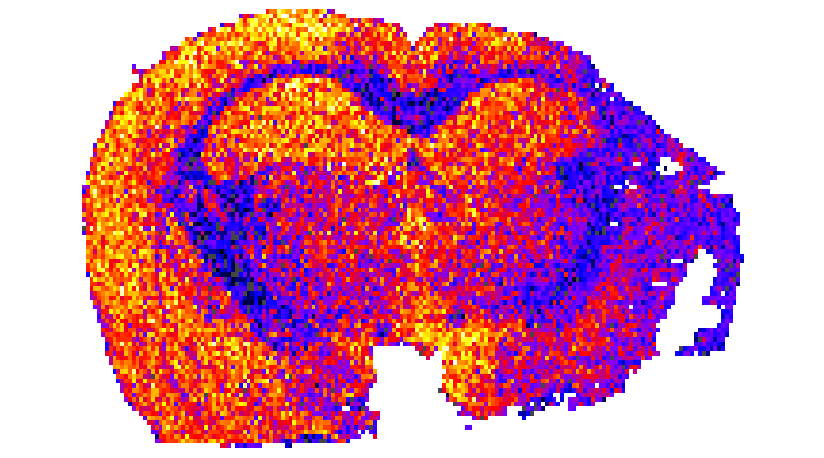

In [34]:
plot_single_mz_animal(
    adata=aad_3,
    mz_val=885.549,
    tol=0.1,
    square_size=60,
    cmap=custom_cmap
)

In [35]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_single_mz_animal(
    adata,
    mz_val,
    tol=0.001,
    vmax_percentile=99.9,
    square_size=60,   # µm
    cmap=None
):
    """
    Plot TIC-normalized intensity for one m/z and one sample,
    with each square representing `square_size` µm × `square_size` µm.
    The figure size is scaled to real physical dimensions.
    """

    # --- Extract m/z index ---
    mz_axis = adata.var_names.astype(float).values
    mz_diff = np.abs(mz_axis - mz_val)
    if np.min(mz_diff) > tol:
        print(f"m/z {mz_val} not found within tolerance {tol}")
        return
    mz_index = np.argmin(mz_diff)

    # --- Extract intensities ---
    intensities = adata.X[:, mz_index].toarray().flatten() if hasattr(adata.X, "toarray") else adata.X[:, mz_index]

    # --- Extract coordinates & TIC ---
    x = adata.obs["x"].values
    y = adata.obs["y"].values
    tic = adata.obs["Processed_TIC"].values

    # Normalize by TIC
    normalized_intensities = intensities / tic
    normalized_intensities = np.nan_to_num(normalized_intensities, nan=0.0, posinf=0.0, neginf=0.0)

    # --- Build grid ---
    x_unique = np.unique(x)
    y_unique = np.unique(y)
    Nx = len(x_unique)
    Ny = len(y_unique)

    grid = np.full((Ny, Nx), np.nan)
    for xi, yi, val in zip(x, y, normalized_intensities):
        x_idx = np.where(x_unique == xi)[0][0]
        y_idx = np.where(y_unique == yi)[0][0]
        grid[y_idx, x_idx] = val

    # --- Scaling ---
    width_um  = Nx * square_size
    height_um = Ny * square_size
    width_in  = width_um / 25400.0   # convert µm → inches
    height_in = height_um / 25400.0

    # --- Color scaling ---
    vmax_value = np.percentile(normalized_intensities, vmax_percentile)

    # --- Plot ---
    plt.figure(figsize=(width_in, height_in))
    extent = [0, width_um, 0, height_um]  # x and y in µm
    plt.imshow(grid, cmap=cmap if cmap else "viridis",
               origin="lower", extent=extent,
               vmin=0, vmax=vmax_value, interpolation="none")

    plt.title(f"{sample_id} m/z={mz_val:.4f} TIC Normalized", fontsize=10)
    plt.xlabel("µm")
    plt.ylabel("µm")
    plt.axis("equal")
    plt.show()

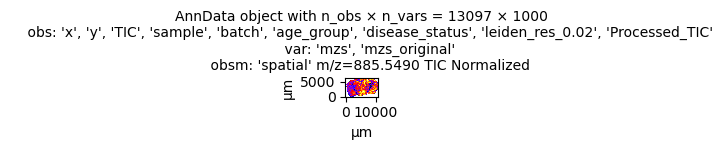

In [40]:
plot_single_mz_animal(
    adata=aad_4,
    mz_val=885.549,
    square_size=60,
    cmap=custom_cmap,
    tol=0.1,
    vmax_percentile=99.9)